Read in data and import packages

In [ ]:
!pip install xgboost
!pip install shap
!pip install --upgrade statsmodels
!pip install "numpy<2"

In [1]:
import pandas as pd
import numpy as np
import scipy as stats
from scipy.stats import ks_2samp, percentileofscore
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, cohen_kappa_score
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
from xgboost import XGBClassifier
import shap
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.discrete.discrete_model import NegativeBinomial
import geopandas as gpd

In [3]:
ticks = pd.read_csv('TickRange.csv')
tbd = pd.read_csv('TBDprevealence.csv')
histNOAA = pd.read_csv('NOAA_weather_data.csv', index_col=0)
histCMIP = pd.read_csv('HistoricalWeather.csv', index_col=0)
futureCMIP = pd.read_csv('FutureWeather.csv', index_col=0)
futureCMIP = futureCMIP.drop(columns=['pr'], axis=1)
raw_future = futureCMIP.copy()
futureCMIP = futureCMIP.copy()

# Bias Correction

Step 1: Organize the data

In [5]:
# find similar counties and determine if any are missing
all_counties = set(histNOAA.COUNTY) & set(histCMIP.COUNTY) & set(futureCMIP.COUNTY)
missing_county = [set(histCMIP.COUNTY).difference(set(histNOAA.COUNTY)), 
                 set(histCMIP.COUNTY).difference(set(futureCMIP.COUNTY)),
                 set(futureCMIP.COUNTY).difference(set(histNOAA.COUNTY))]
print(f" Numer of counties in all data: {len(all_counties)}")
print(f" Missing counties: {missing_county}")

# drop Grant county from CMIP data
histCMIP = histCMIP[histCMIP.COUNTY != 'Grant']
futureCMIP = futureCMIP[futureCMIP.COUNTY != 'Grant']

# split histCMIP into the historical ssp and modeled ssp (126, 245 and 585) datasets
hist_ssp = histCMIP[histCMIP.SSP == 'historical']
hist_model = histCMIP[histCMIP.SSP != 'historical']

 Numer of counties in all data: 87
 Missing counties: [set(), set(), set()]


Step 2: Define the quantile delta mapping function

In [7]:
def qdm_correct(obs, hist, future):
    corrected = []
    for value in future:
        tau = np.clip(percentileofscore(future, value, kind='rank'), 0, 100)
        hist_quant = np.percentile(hist, tau)
        delta = value - hist_quant
        obs_quant = np.percentile(obs, tau)
        corrected_value = obs_quant + delta
        corrected.append(corrected_value)
    return corrected

Step 3: Write the loop that will apply the qdm to the data

In [9]:
# Initialize the lists to iterate over
months = [1,2,3,11,12]
winter_vars = ['TMAX', 'TMIN']
ssps = ['ssp126', 'ssp245', 'ssp585']

for county in all_counties:
    for month in months:
      obs = histNOAA[(histNOAA.COUNTY == county) & (histNOAA.MONTH == month)]
      hist = hist_ssp[(hist_ssp.COUNTY == county) & (hist_ssp.MONTH == month)]
      for var in winter_vars:
        obs_vars = np.array(obs[var])
        obs_vars = obs_vars[~np.isnan(obs_vars)] # Cleans the variable array
        hist_vars = np.array(hist[var])
        hist_vars = hist_vars[~np.isnan(hist_vars)]
        for ssp in ssps: 
            futr = futureCMIP[(futureCMIP.COUNTY == county) & (futureCMIP.MONTH == month) & (futureCMIP.SSP == ssp)]
            futr_vars = np.array(futr[var])
            futr_vars = futr_vars[~np.isnan(futr_vars)]
            if len(obs_vars) == 0 or len(hist_vars) == 0: # ensures that empty arrays due to any given reason do not break the function
              continue
            corrected_CMIP = qdm_correct(obs_vars, hist_vars, futr_vars)
            futureCMIP.loc[(futureCMIP.COUNTY == county) & (futureCMIP.MONTH == month) & (futureCMIP.SSP == ssp), var] = corrected_CMIP
futureCMIP['SNOW'] = raw_future['SNOW']

In [9]:
# Save to csv
futureCMIP.to_csv('CorrectedFutureWeather.csv')

Step 4: Evaluate the correction

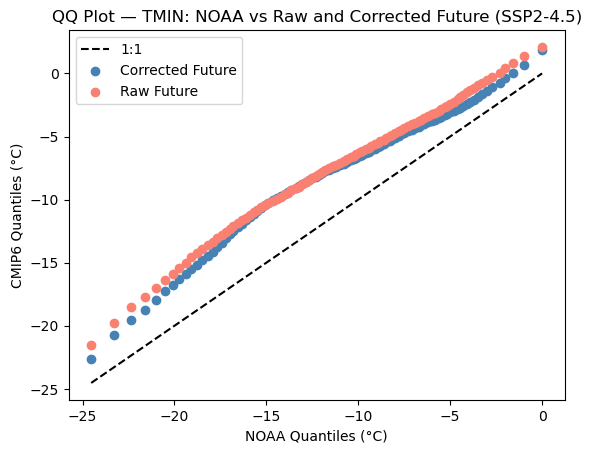

In [11]:
# Create QQ plots to see how model performed
noaaTMIN = np.array(histNOAA.TMIN) 
noaaTMIN = noaaTMIN[~np.isnan(noaaTMIN)]
futureTMIN = np.array(futureCMIP.TMIN) 
futureTMIN = futureTMIN[~np.isnan(futureTMIN)]
rawTMIN = np.array(raw_future.TMIN) 
rawTMIN = rawTMIN[~np.isnan(rawTMIN)]
quantiles = np.arange(1,100)
noaa_quantiles = np.percentile(noaaTMIN, quantiles)
future_quantiles = np.percentile(futureTMIN, quantiles)
raw_quantiles = np.percentile(rawTMIN, quantiles)

plt.plot([noaa_quantiles.min(), noaa_quantiles.max()], 
         [noaa_quantiles.min(), noaa_quantiles.max()], 
         'k--', label='1:1')
plt.scatter(noaa_quantiles, future_quantiles, color='steelblue', label='Corrected Future')
plt.scatter(noaa_quantiles, raw_quantiles, color='salmon', label='Raw Future')
plt.xlabel("NOAA Quantiles (°C)")
plt.ylabel("CMIP6 Quantiles (°C)")
plt.title("QQ Plot — TMIN: NOAA vs Raw and Corrected Future (SSP2-4.5)")
plt.legend()
plt.savefig('TMIN-QQ.png')
plt.show()

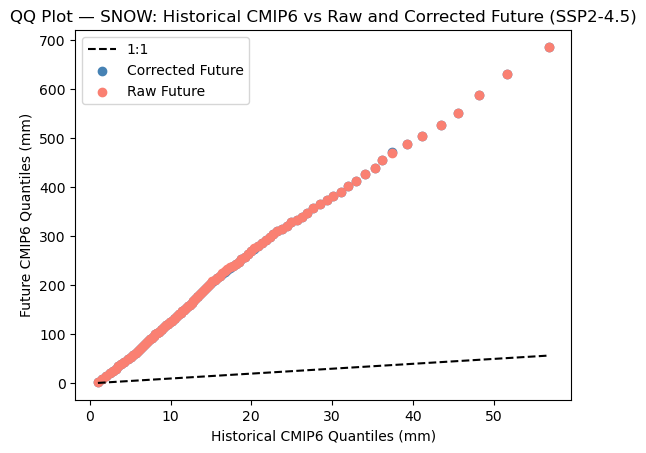

In [13]:
# Repeat for SNOW variable 
histSNOW = np.array(hist_ssp.SNOW)
histSNOW = histSNOW[~np.isnan(histSNOW)]
futureSNOW = np.array(futureCMIP[futureCMIP.SSP == 'ssp245'].SNOW)
futureSNOW = futureSNOW[~np.isnan(futureSNOW)]
rawSNOW = np.array(raw_future[raw_future.SSP == 'ssp245'].SNOW)
rawSNOW = rawSNOW[~np.isnan(rawSNOW)]
quantiles = np.arange(1, 100)
hist_quantiles = np.percentile(histSNOW, quantiles)
future_quantiles = np.percentile(futureSNOW, quantiles)
raw_quantiles = np.percentile(rawSNOW, quantiles)

plt.plot([hist_quantiles.min(), hist_quantiles.max()],
         [hist_quantiles.min(), hist_quantiles.max()],
         'k--', label='1:1')
plt.scatter(hist_quantiles, future_quantiles, color='steelblue', label='Corrected Future')
plt.scatter(hist_quantiles, raw_quantiles, color='salmon', label='Raw Future')
plt.xlabel("Historical CMIP6 Quantiles (mm)")
plt.ylabel("Future CMIP6 Quantiles (mm)")
plt.title("QQ Plot — SNOW: Historical CMIP6 vs Raw and Corrected Future (SSP2-4.5)")
plt.legend()
plt.savefig('SNOW-QQ.png')
plt.show()

# Random Forest

Step 1: Feature engineering

In [15]:
futureCMIP = pd.read_csv('CorrectedFutureWeather.csv')

In [17]:
winter_vars_tot = ['TMIN', 'TMAX', 'SNOW']
noaa_96 = histNOAA[(histNOAA.YEAR < 1996) | ((histNOAA.YEAR == 1996) & (histNOAA.MONTH < 4))]
noaa_mean_96 = noaa_96.groupby(['COUNTY', 'MONTH'])[winter_vars_tot].mean()
noaa_std_96 = noaa_96.groupby(['COUNTY', 'MONTH'])[winter_vars_tot].std()

noaa_15 = histNOAA[((histNOAA.YEAR < 2015) & (histNOAA.YEAR >= 1996)) | ((histNOAA.YEAR == 2015) & (histNOAA.MONTH < 4))]
noaa_mean_15 = noaa_15.groupby(['COUNTY', 'MONTH'])[winter_vars_tot].mean()
noaa_std_15 = noaa_15.groupby(['COUNTY', 'MONTH'])[winter_vars_tot].std()

noaa_24 = histNOAA[((histNOAA.YEAR < 2024) & (histNOAA.YEAR >= 2015)) | ((histNOAA.YEAR == 2024) & (histNOAA.MONTH < 4))]
noaa_mean_24 = noaa_24.groupby(['COUNTY', 'MONTH'])[winter_vars_tot].mean()
noaa_std_24 = noaa_24.groupby(['COUNTY', 'MONTH'])[winter_vars_tot].std()

#Pivot to wide format
noaa96_mean_wide = noaa_mean_96.unstack()
noaa96_std_wide = noaa_std_96.unstack()
noaa15_mean_wide = noaa_mean_15.unstack()
noaa15_std_wide = noaa_std_15.unstack()
noaa24_mean_wide = noaa_mean_24.unstack()
noaa24_std_wide = noaa_std_24.unstack()

In [19]:
# Flatten MultiIndex columns to single string e.g. ('TMIN', 1) -> 'TMIN_1'
noaa96_mean_wide.columns = ['_'.join([var, str(month)]) for (var, month) in noaa96_mean_wide.columns]
noaa96_std_wide.columns = ['_'.join([var, str(month)]) for (var, month) in noaa96_std_wide.columns]
noaa15_mean_wide.columns = ['_'.join([var, str(month)]) for (var, month) in noaa15_mean_wide.columns]
noaa15_std_wide.columns = ['_'.join([var, str(month)]) for (var, month) in noaa15_std_wide.columns]
noaa24_mean_wide.columns = ['_'.join([var, str(month)]) for (var, month) in noaa24_mean_wide.columns]
noaa24_std_wide.columns = ['_'.join([var, str(month)]) for (var, month) in noaa24_std_wide.columns]

# Add _mean and _std suffixes to distinguish feature types e.g. 'TMIN_1' -> 'TMIN_1_mean'
noaa96_mean_wide = noaa96_mean_wide.add_suffix('_mean')
noaa96_std_wide = noaa96_std_wide.add_suffix('_std')
noaa15_mean_wide = noaa15_mean_wide.add_suffix('_mean')
noaa15_std_wide = noaa15_std_wide.add_suffix('_std')
noaa24_mean_wide = noaa24_mean_wide.add_suffix('_mean')  # fixed: was noaa15
noaa24_std_wide = noaa24_std_wide.add_suffix('_std')    # fixed: was noaa15

In [21]:
# Join to have one dataframe for the 1996 snapshot and one dataframe for the 2015 snapshot
snapshot_96 = noaa96_mean_wide.join(noaa96_std_wide, how = 'left')
snapshot_15 = noaa15_mean_wide.join(noaa15_std_wide, how = 'left')

# Add tick labels
ticks.set_index(ticks.COUNTY, inplace = True)
snapshot_96['LABEL'] = ticks['VALUE_1996']
snapshot_15['LABEL'] = ticks['VALUE_2015']

#Combine into a training dataframe
train = pd.concat([snapshot_96, snapshot_15])

# Join 2024 dataframes for the test set
snapshot_24 = noaa24_mean_wide.join(noaa24_std_wide, how = 'left')

#Add tick labels and rename for the test set
snapshot_24['LABEL'] = ticks['VALUE_2024']
test = snapshot_24

print(train.shape)
print(test.shape)

(169, 31)
(79, 31)


In [23]:
X_train = train.drop(columns=['LABEL'])
y_train = train['LABEL']
X_test = test.drop(columns=['LABEL'])
y_test = test['LABEL']

Step 2: Build the model

In [25]:

SEED = 1

# Impute missing values
imputer = KNNImputer(n_neighbors=4)
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Instantiate RF
rf = RandomForestClassifier(class_weight='balanced', random_state=SEED)

# Define parameter grid
grid = { 
    'n_estimators': [300, 400, 500, 600],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [4, 5, 6, 7, 8],
    'min_samples_leaf': [3, 4, 5, 6, 7],
    'criterion': ['gini', 'entropy']
}

# Grid search
search = GridSearchCV(rf, grid, scoring='f1_weighted', cv=10, n_jobs=-1)
search.fit(X_train_imputed, y_train)

print(search.best_params_)
print(search.best_score_)

C:\Users\abiga\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


{'criterion': 'entropy', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 600}
0.7330719780027739


C:\Users\abiga\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\abiga\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\abiga\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.23      0.93      0.36        15
           1       0.00      0.00      0.00         3
           2       0.94      0.26      0.41        61

    accuracy                           0.38        79
   macro avg       0.39      0.40      0.26        79
weighted avg       0.77      0.38      0.39        79



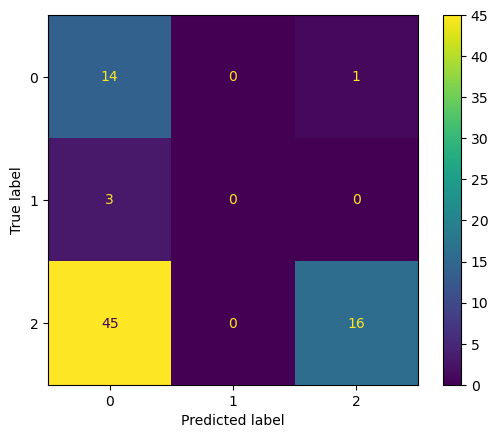

In [29]:
# Redefine rf with best parameters found from grid search
rf = RandomForestClassifier(criterion='entropy', n_estimators=600, max_depth=7, 
                             max_features='sqrt', min_samples_leaf=3, 
                             class_weight='balanced', random_state=SEED)
rf.fit(X_train_imputed, y_train)
y_pred = rf.predict(X_test_imputed)

# Evaluate via confusion matrix
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=[0,1,2]).plot()
plt.savefig('RFconfusion.png')
plt.show()

In [31]:
# Manually adjust threshold
y_proba_rf = rf.predict_proba(X_test_imputed)
print(y_proba_rf[:5])

predictions_24_rf = []
threshold = 0.22
for probs in y_proba_rf:
    if probs[2] >= threshold:
        predictions_24_rf.append(2)
    else:
        predictions_24_rf.append(np.argmax(probs))
print(classification_report(y_test, predictions_24_rf))

[[0.47972072 0.23469642 0.28558286]
 [0.4150749  0.13906885 0.44585626]
 [0.43961924 0.10393455 0.45644621]
 [0.49185234 0.31051234 0.19763531]
 [0.49243315 0.24097168 0.26659518]]
              precision    recall  f1-score   support

           0       0.33      0.20      0.25        15
           1       0.00      0.00      0.00         3
           2       0.79      0.90      0.84        61

    accuracy                           0.73        79
   macro avg       0.37      0.37      0.36        79
weighted avg       0.67      0.73      0.70        79



C:\Users\abiga\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\abiga\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\abiga\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


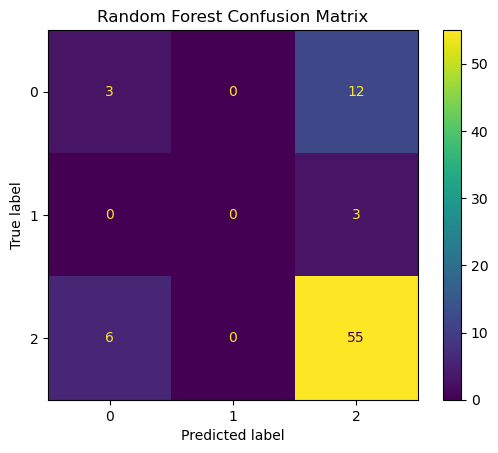

In [33]:
# Reevaluate via confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, predictions_24_rf), display_labels=[0,1,2]).plot()
plt.title('Random Forest Confusion Matrix')
plt.savefig('RFconfusion.png')
plt.show()

# XGBoost

In [35]:
# Handle imbalance 
weight = compute_sample_weight('balanced', y_train)

# Instantiate the xgboost
xg_cl = xgb.XGBClassifier(n_estimators=56, max_depth=7, learning_rate=0.05,
                                  subsample=0.8, colsample_bytree=0.8,
                                  objective='multi:softprob', num_class=3,
                                  eval_metric='mlogloss', random_state=SEED)

# Fit and predict
xg_cl.fit(X_train_imputed, y_train, sample_weight = weight)
y_pred = xg_cl.predict(X_test_imputed)

#Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.21      0.80      0.33        15
           1       0.00      0.00      0.00         3
           2       0.81      0.21      0.34        61

    accuracy                           0.32        79
   macro avg       0.34      0.34      0.22        79
weighted avg       0.67      0.32      0.32        79



In [37]:
# Cross-Validation
# Dmatrix
dtrain = xgb.DMatrix(data = X_train_imputed, label = y_train, weight = weight)

# Parameters dictionary
params = {
    'objective': 'multi:softprob',
    'num_class': 3,
    'max_depth': 7,
    'eta': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'mlogloss',
    'seed': SEED
}
# Tuned results
tuned_results = xgb.cv(dtrain = dtrain, params = params, nfold = 10, num_boost_round = 600, early_stopping_rounds = 50)

print(tuned_results.tail())
print(f"Best number of trees: {tuned_results['test-mlogloss-mean'].idxmin()}")
print(f"Best mlogloss: {tuned_results['test-mlogloss-mean'].min():.4f}")

    train-mlogloss-mean  train-mlogloss-std  test-mlogloss-mean  \
52             0.193772            0.003287            0.734726   
53             0.189248            0.003301            0.734264   
54             0.185023            0.003368            0.734670   
55             0.180723            0.003288            0.733780   
56             0.176495            0.003369            0.732104   

    test-mlogloss-std  
52           0.273759  
53           0.277229  
54           0.279367  
55           0.281824  
56           0.284117  
Best number of trees: 56
Best mlogloss: 0.7321


In [40]:
# Manually adjust threshodld
y_proba_xg = xg_cl.predict_proba(X_test_imputed)
print(y_proba_xg[:5])
predictions_24_xg = []
threshold = 0.22
for probs in y_proba_xg:
    if probs[2] >= threshold:
        predictions_24_xg.append(2)
    else:
        predictions_24_xg.append(np.argmax(probs))
print(classification_report(y_test, predictions_24_xg))

[[0.419634   0.23391376 0.3464522 ]
 [0.35602784 0.09231932 0.5516528 ]
 [0.41650486 0.21099904 0.37249607]
 [0.3875719  0.40607128 0.20635684]
 [0.55929184 0.2786311  0.16207705]]
              precision    recall  f1-score   support

           0       0.33      0.33      0.33        15
           1       0.00      0.00      0.00         3
           2       0.80      0.80      0.80        61

    accuracy                           0.68        79
   macro avg       0.38      0.38      0.38        79
weighted avg       0.68      0.68      0.68        79



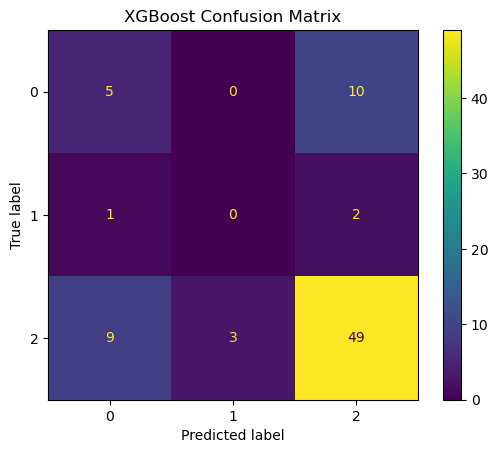

In [42]:
# Evaluate via confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, predictions_24_xg), display_labels=[0,1,2]).plot()
plt.title('XGBoost Confusion Matrix')
plt.savefig('XGBconfusion.png')
plt.show()

# Model Evaluation

In [52]:
# RF classification report
report_rf = classification_report(y_test, predictions_24_rf, 
                                   target_names=['No Records', 'Reported', 'Established'],
                                   output_dict=True)
classification_rf = pd.DataFrame(report_rf).transpose()
columns = {'precision':'RF Precision', 'recall':'RF Recall', 'f1-score':'RF F1-score', 'support':'RF Support'}
classification_rf = classification_rf.rename(columns = columns)
print(classification_rf)

              RF Precision  RF Recall  RF F1-score  RF Support
No Records        0.333333   0.200000     0.250000   15.000000
Reported          0.000000   0.000000     0.000000    3.000000
Established       0.785714   0.901639     0.839695   61.000000
accuracy          0.734177   0.734177     0.734177    0.734177
macro avg         0.373016   0.367213     0.363232   79.000000
weighted avg      0.669982   0.734177     0.695840   79.000000


C:\Users\abiga\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\abiga\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\abiga\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [54]:
# XGBoost classification report
report_xg = classification_report(y_test, predictions_24_xg, 
                                   target_names=['No Records', 'Reported', 'Established'],
                                   output_dict=True)
classification_xg = pd.DataFrame(report_xg).transpose()
columns = {'precision':'XGBoost Precision', 'recall':'XGBoost Recall', 'f1-score':'XGBoost F1-score', 'support':'XGBoost Support'}
classification_xg = classification_xg.rename(columns = columns)
print(classification_xg)

              XGBoost Precision  XGBoost Recall  XGBoost F1-score  \
No Records             0.333333        0.333333          0.333333   
Reported               0.000000        0.000000          0.000000   
Established            0.803279        0.803279          0.803279   
accuracy               0.683544        0.683544          0.683544   
macro avg              0.378871        0.378871          0.378871   
weighted avg           0.683544        0.683544          0.683544   

              XGBoost Support  
No Records          15.000000  
Reported             3.000000  
Established         61.000000  
accuracy             0.683544  
macro avg           79.000000  
weighted avg        79.000000  


In [56]:
# Combine classifications inito one table and save as CSV
classification_combined = classification_rf.join(classification_xg)
classification_combined = classification_combined.round(3)
classification_combined.to_csv('ClassificationReportResults.csv')
print(classification_combined.head())

             RF Precision  RF Recall  RF F1-score  RF Support  \
No Records          0.333      0.200        0.250      15.000   
Reported            0.000      0.000        0.000       3.000   
Established         0.786      0.902        0.840      61.000   
accuracy            0.734      0.734        0.734       0.734   
macro avg           0.373      0.367        0.363      79.000   

             XGBoost Precision  XGBoost Recall  XGBoost F1-score  \
No Records               0.333           0.333             0.333   
Reported                 0.000           0.000             0.000   
Established              0.803           0.803             0.803   
accuracy                 0.684           0.684             0.684   
macro avg                0.379           0.379             0.379   

             XGBoost Support  
No Records            15.000  
Reported               3.000  
Established           61.000  
accuracy               0.684  
macro avg             79.000  


# SHAP

For Random Forest

C:\Users\abiga\AppData\Local\Temp\ipykernel_33104\2054573814.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_class2, X_test_imputed,


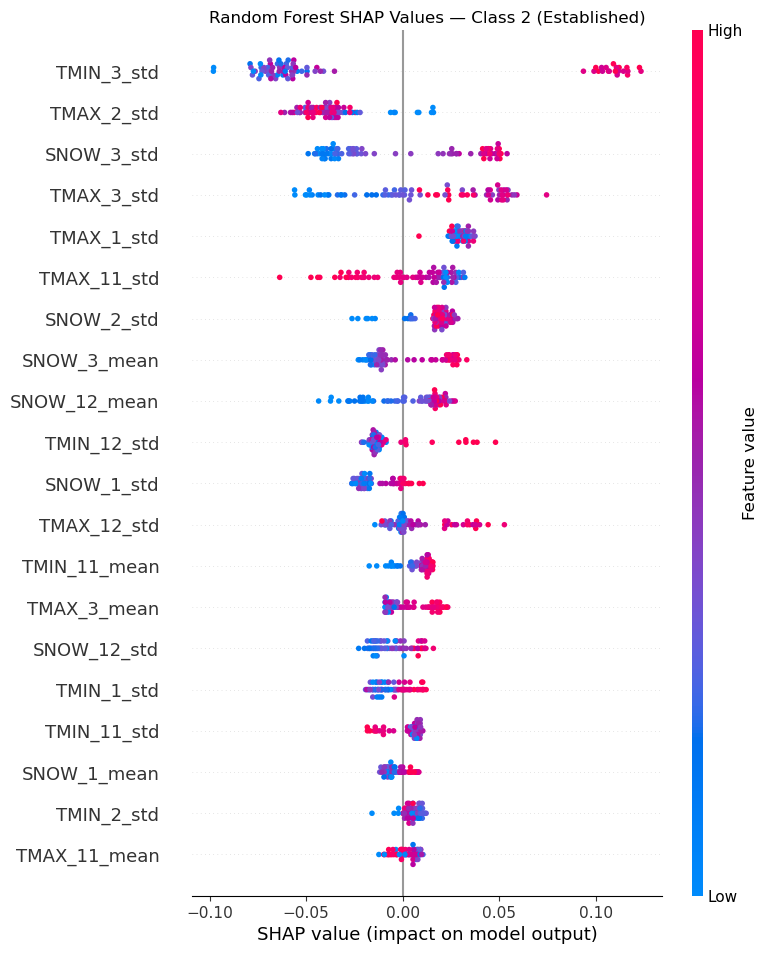

In [58]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_imputed)
shap_values_class2 = shap_values[:, :, 2]

# Visualize the important features
shap.summary_plot(shap_values_class2, X_test_imputed, 
                  feature_names=X_train.columns,
                  show=False)
plt.title('Random Forest SHAP Values — Class 2 (Established)')
plt.savefig('SHAP_RF_Established.png', bbox_inches='tight', dpi=150)
plt.show()

C:\Users\abiga\AppData\Local\Temp\ipykernel_33104\3203876274.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_class2, X_test_imputed,


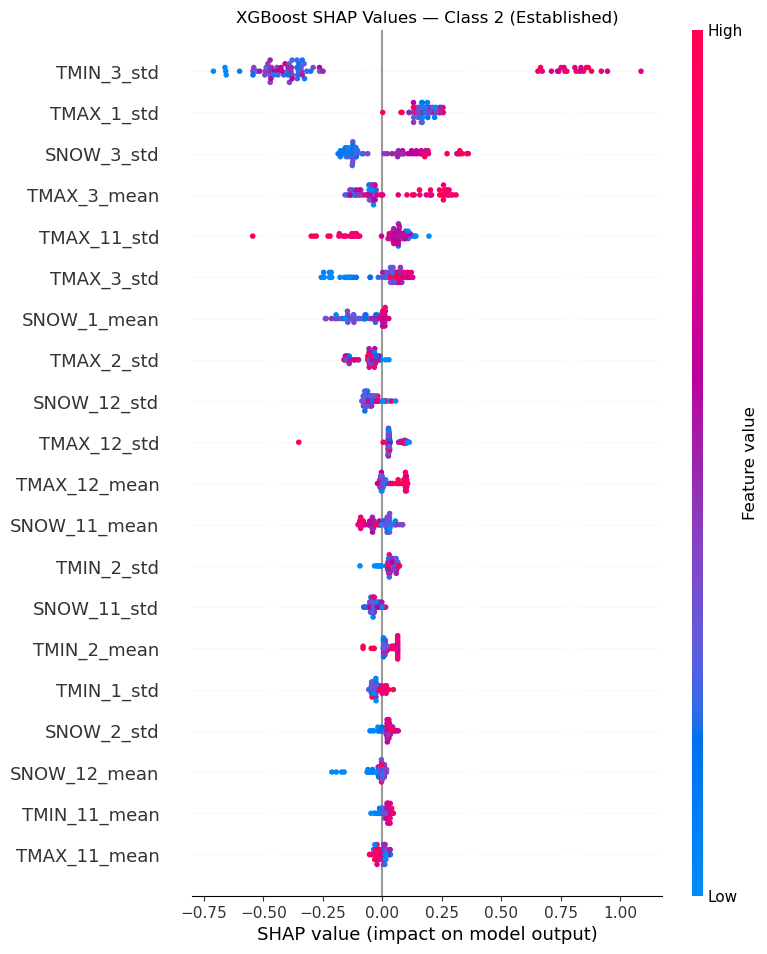

In [60]:
explainer = shap.TreeExplainer(xg_cl)
shap_values = explainer.shap_values(X_test_imputed)
shap_values_class2 = shap_values[:, :, 2]

# Visualize the important features
shap.summary_plot(shap_values_class2, X_test_imputed, 
                  feature_names=X_train.columns,
                  show=False)
plt.title('XGBoost SHAP Values — Class 2 (Established)')
plt.savefig('SHAP_XGBoost_Established.png', bbox_inches='tight', dpi=150)
plt.show()

# Future Predictions

Feature Engineering

In [62]:
winter_vars_tot = ['TMIN', 'TMAX', 'SNOW']
# SSP126
ssp126 = futureCMIP[futureCMIP['SSP'] == 'ssp126']
ssp126_mean = ssp126.groupby(['COUNTY', 'MONTH'])[winter_vars_tot].mean()
ssp126_std = ssp126.groupby(['COUNTY', 'MONTH'])[winter_vars_tot].std()

#SSP245
ssp245 = futureCMIP[futureCMIP['SSP'] == 'ssp245']
ssp245_mean = ssp245.groupby(['COUNTY', 'MONTH'])[winter_vars_tot].mean()
ssp245_std = ssp245.groupby(['COUNTY', 'MONTH'])[winter_vars_tot].std()

#SSP585
ssp585 = futureCMIP[futureCMIP['SSP'] == 'ssp585']
ssp585_mean = ssp585.groupby(['COUNTY', 'MONTH'])[winter_vars_tot].mean()
ssp585_std = ssp585.groupby(['COUNTY', 'MONTH'])[winter_vars_tot].std()

#Pivot to wide format
ssp126_mean_wide = ssp126_mean.unstack()
ssp126_std_wide = ssp126_std.unstack()
ssp245_mean_wide = ssp245_mean.unstack()
ssp245_std_wide = ssp245_std.unstack()
ssp585_mean_wide = ssp585_mean.unstack()
ssp585_std_wide = ssp585_std.unstack()

In [64]:
# Flatten MultiIndex columns to single string e.g. ('TMIN', 1) -> 'TMIN_1'
ssp126_mean_wide.columns = ['_'.join([var, str(month)]) for (var, month) in ssp126_mean_wide.columns]
ssp126_std_wide.columns = ['_'.join([var, str(month)]) for (var, month) in ssp126_std_wide.columns]
ssp245_mean_wide.columns = ['_'.join([var, str(month)]) for (var, month) in ssp245_mean_wide.columns]
ssp245_std_wide.columns = ['_'.join([var, str(month)]) for (var, month) in ssp245_std_wide.columns]
ssp585_mean_wide.columns = ['_'.join([var, str(month)]) for (var, month) in ssp585_mean_wide.columns]
ssp585_std_wide.columns = ['_'.join([var, str(month)]) for (var, month) in ssp585_std_wide.columns]

# Add _mean and _std suffixes to distinguish feature types e.g. 'TMIN_1' -> 'TMIN_1_mean'
ssp126_mean_wide = ssp126_mean_wide.add_suffix('_mean')
ssp126_std_wide = ssp126_std_wide.add_suffix('_std')
ssp245_mean_wide = ssp245_mean_wide.add_suffix('_mean')
ssp245_std_wide = ssp245_std_wide.add_suffix('_std')
ssp585_mean_wide = ssp585_mean_wide.add_suffix('_mean') 
ssp585_std_wide = ssp585_std_wide.add_suffix('_std')    

In [76]:
# Join to have one dataframe for each ssp
snapshot_ssp126 = ssp126_mean_wide.join(ssp126_std_wide, how = 'left')
snapshot_ssp245 = ssp245_mean_wide.join(ssp245_std_wide, how = 'left')
snapshot_ssp585 = ssp585_mean_wide.join(ssp585_std_wide, how = 'left')

print(snapshot_ssp126.shape)
print(snapshot_ssp245.shape)
print(snapshot_ssp585.shape)

(86, 30)
(86, 30)
(86, 30)


Random Forest

In [78]:
# SSP126
y_proba = rf.predict_proba(snapshot_ssp126)
predictions_ssp126 = []
threshold = 0.22
for probs in y_proba:
    if probs[2] >= threshold:
        predictions_ssp126.append(2)
    else:
        predictions_ssp126.append(np.argmax(probs))

# SSP245
y_proba = rf.predict_proba(snapshot_ssp245)
predictions_ssp245 = []
threshold = 0.22
for probs in y_proba:
    if probs[2] >= threshold:
        predictions_ssp245.append(2)
    else:
        predictions_ssp245.append(np.argmax(probs))

# SSP585
y_proba = rf.predict_proba(snapshot_ssp585)
predictions_ssp585 = []
threshold = 0.22
for probs in y_proba:
    if probs[2] >= threshold:
        predictions_ssp585.append(2)
    else:
        predictions_ssp585.append(np.argmax(probs))

# Check values
print(pd.Series(predictions_ssp126).value_counts())
print(pd.Series(predictions_ssp245).value_counts())
print(pd.Series(predictions_ssp585).value_counts())

2    82
1     4
Name: count, dtype: int64
2    81
1     4
0     1
Name: count, dtype: int64
2    86
Name: count, dtype: int64


C:\Users\abiga\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\abiga\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\abiga\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


XGBoost

In [80]:
# SSP126
y_proba = xg_cl.predict_proba(snapshot_ssp126)
predictions_ssp126_xg = []
threshold = 0.22
for probs in y_proba:
    if probs[2] >= threshold:
        predictions_ssp126_xg.append(2)
    else:
        predictions_ssp126_xg.append(np.argmax(probs))

# SSP245
y_proba = xg_cl.predict_proba(snapshot_ssp245)
predictions_ssp245_xg = []
threshold = 0.22
for probs in y_proba:
    if probs[2] >= threshold:
        predictions_ssp245_xg.append(2)
    else:
        predictions_ssp245_xg.append(np.argmax(probs))

# SSP585
y_proba = xg_cl.predict_proba(snapshot_ssp585)
predictions_ssp585_xg = []
threshold = 0.22
for probs in y_proba:
    if probs[2] >= threshold:
        predictions_ssp585_xg.append(2)
    else:
        predictions_ssp585_xg.append(np.argmax(probs))

# Check values
print(pd.Series(predictions_ssp126_xg).value_counts())
print(pd.Series(predictions_ssp245_xg).value_counts())
print(pd.Series(predictions_ssp585_xg).value_counts())

2    72
1    14
Name: count, dtype: int64
2    76
1     9
0     1
Name: count, dtype: int64
2    84
0     2
Name: count, dtype: int64


Save outputs

In [72]:
# Save the test results
test_columns = {
    'RF_2024_TEST': predictions_24_rf,
    'XGB_2024_TEST': predictions_24_xg
}
test_results = pd.DataFrame(test_columns, index = snapshot_24.index)
print(test_results.head())
# Save the future results
columns = {
    'RF_ssp126': predictions_ssp126,
    'RF_ssp245': predictions_ssp245,
    'RF_ssp585': predictions_ssp585,
    'XGB_ssp126': predictions_ssp126_xg,
    'XGB_ssp245': predictions_ssp245_xg,
    'XGB_ssp585': predictions_ssp585_xg,
}
future_results = pd.DataFrame(columns, index=snapshot_ssp126.index)
print(future_results.head())

          RF_2024_TEST  XGB_2024_TEST
COUNTY                               
Aitkin               2              2
Anoka                2              2
Becker               2              2
Beltrami             0              1
Benton               2              0
          RF_ssp126  RF_ssp245  RF_ssp585  XGB_ssp126  XGB_ssp245  XGB_ssp585
COUNTY                                                                       
Aitkin            2          2          2           2           2           2
Anoka             2          2          2           2           2           2
Becker            2          2          2           1           2           2
Beltrami          2          2          2           1           2           2
Benton            2          2          2           2           2           2


In [300]:
test_results.to_csv('TestResults.csv')
future_results.to_csv('FutureResults.csv')

# Poisson

In [84]:
future_results = pd.read_csv('FutureResults.csv')
test_results = pd.read_csv('TestResults.csv')
tbd = pd.read_csv('TBDprevealence.csv')
ticks = pd.read_csv('TickRange.csv')

Step 1: Feature Engineering

In [86]:
# Create a habitability score
map = {0:0, 1:0.3, 2:1.0} # weights
anchor_scores = pd.DataFrame()
known_habitat = {}
columns = ['VALUE_1996', 'VALUE_2015', 'VALUE_2024']
for column in columns:
  anchor_scores[column] = ticks[column].map(map)
  year = int(column.split('_')[1])
  known_habitat.update({year:anchor_scores[column].mean()})

habitat_scores = pd.Series(data = np.nan, index = range(1996, 2025))
for key, value in known_habitat.items():
  habitat_scores[key] = value
habitat_scores = habitat_scores.interpolate(method='linear')

habitat_scores = pd.DataFrame(habitat_scores)
habitat_scores.reset_index(inplace = True)
habitat_scores.columns = ['YEAR', 'SCORE']
tbd.rename(columns = {'Year' : 'YEAR'}, inplace = True)
tbd = habitat_scores.merge(tbd, on = 'YEAR')
tbd = tbd[tbd['YEAR'] <= 2023]
tbd['Total Population (in thousands)'] = pd.to_numeric(tbd['Total Population (in thousands)']) * 1000

In [88]:
# Feature Matrix
tbd_lyme = tbd[tbd.YEAR != 2020]
y_lyme = tbd_lyme['Lyme disease']
log_pop = np.log(tbd_lyme['Total Population (in thousands)'])
X_lyme = tbd_lyme['SCORE']
X_lyme = sm.add_constant(X_lyme)

Step 2: Build the model

In [90]:
# Step 2: instantiate and fit model
poisson = sm.GLM(y_lyme, X_lyme, offset = log_pop, family=sm.families.Poisson()).fit()
print(poisson.summary())

# Anaplasmosis
tbd_other = tbd[(tbd.YEAR != 2020) & (tbd.YEAR > 2010)]
y_ana = tbd_other['Anaplasmosis']
log_pop_other = np.log(tbd_other['Total Population (in thousands)'])
X_other = tbd_other['SCORE']
X_other = sm.add_constant(X_other)

poisson_ana = sm.GLM(y_ana, X_other, offset = log_pop_other, family=sm.families.Poisson()).fit()

# Ehrlichiosis
y_ehrl = tbd_other['Ehrlichiosis']


poisson_ehrl = sm.GLM(y_ehrl, X_other, offset = log_pop_other, family=sm.families.Poisson()).fit()

# Undetermined
y_undet = tbd_other['Undetermined E/A']

poisson_undet = sm.GLM(y_undet, X_other, offset = log_pop_other, family=sm.families.Poisson()).fit()

# Babesiosis
y_bab = tbd_other['Babesiosis']

poisson_bab = sm.GLM(y_bab, X_other, offset = log_pop_other, family=sm.families.Poisson()).fit()

                 Generalized Linear Model Regression Results                  
Dep. Variable:           Lyme disease   No. Observations:                   26
Model:                            GLM   Df Residuals:                       24
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2100.9
Date:                Sat, 18 Apr 2026   Deviance:                       3973.6
Time:                        14:06:30   Pearson chi2:                 3.97e+03
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -9.7635      0.020   -487.627      0.0

Step 3: Model evaluation and tuning

In [92]:
# Model evaluation and tuning
overdisp_lyme = poisson.pearson_chi2 / poisson.df_resid
overdisp_ana = poisson_ana.pearson_chi2 / poisson_ana.df_resid
overdisp_ehrl = poisson_ehrl.pearson_chi2 / poisson_ehrl.df_resid
overdisp_undet = poisson_undet.pearson_chi2 / poisson_undet.df_resid
overdisp_bab = poisson_bab.pearson_chi2 / poisson_bab.df_resid

print('-----Overdispersion Check-----')
print(f" Lyme: {overdisp_lyme:.3f}")
print(f" Anaplasmosis: {overdisp_ana:.3f}")
print(f" Ehrlichiosis: {overdisp_ehrl:.3f}")
print(f" Undetermined: {overdisp_undet:.3f}")
print(f" Babesiosis: {overdisp_bab:.3f}")

autocorr_lyme = durbin_watson(poisson.resid_pearson)
autocorr_ana = durbin_watson(poisson_ana.resid_pearson)
autocorr_ehrl = durbin_watson(poisson_ehrl.resid_pearson)
autocorr_undet = durbin_watson(poisson_undet.resid_pearson)
autocorr_bab = durbin_watson(poisson_bab.resid_pearson)

print('-----Autocorrelation Check-----')
print(f" Lyme: {autocorr_lyme:.3f}")
print(f" Anaplasmosis: {autocorr_ana:.3f}")
print(f" Ehrlichiosis: {autocorr_ehrl:.3f}")
print(f" Undetermined: {autocorr_undet:.3f}")
print(f" Babesiosis: {autocorr_bab:.3f}")

deviance_lyme = poisson.deviance / poisson.df_resid
deviance_ana = poisson_ana.deviance / poisson_ana.df_resid
deviance_ehrl = poisson_ehrl.deviance / poisson_ehrl.df_resid
deviance_undet = poisson_undet.deviance / poisson_undet.df_resid
deviance_bab = poisson_bab.deviance / poisson_bab.df_resid

print('-----Deviance-----')
print(f" Lyme: {deviance_lyme:.3f}")
print(f" Anaplasmosis: {deviance_ana:.3f}")
print(f" Ehrlichiosis: {deviance_ehrl:.3f}")
print(f" Undetermined: {deviance_undet:.3f}")
print(f" Babesiosis: {deviance_bab:.3f}")

aic_L_baseline = poisson.aic
aic_A_baseline = poisson_ana.aic
aic_E_baseline = poisson_ehrl.aic
aic_U_baseline = poisson_undet.aic
aic_B_baseline = poisson_bab.aic

print('-----Baseline AIC-----')
print(f" Lyme: {aic_L_baseline:.3f}")
print(f" Anaplasmosis: {aic_A_baseline:.3f}")
print(f" Ehrlichiosis: {aic_E_baseline:.3f}")
print(f" Undetermined: {aic_U_baseline:.3f}")
print(f" Babesiosis: {aic_B_baseline:.3f}")

pseudo_r2_lyme = poisson.pseudo_rsquared()
pseudo_r2_ana = poisson_ana.pseudo_rsquared()
pseudo_r2_ehrl = poisson_ehrl.pseudo_rsquared()
pseudo_r2_undet = poisson_undet.pseudo_rsquared()
pseudo_r2_bab = poisson_bab.pseudo_rsquared()

print('-----Pseudo R²-----')
print(f" Lyme: {pseudo_r2_lyme:.3f}")
print(f" Anaplasmosis: {pseudo_r2_ana:.3f}")
print(f" Ehrlichiosis: {pseudo_r2_ehrl:.3f}")
print(f" Undetermined: {pseudo_r2_undet:.3f}")
print(f" Babesiosis: {pseudo_r2_bab:.3f}")

-----Overdispersion Check-----
 Lyme: 165.577
 Anaplasmosis: 21.691
 Ehrlichiosis: 1.056
 Undetermined: 7.304
 Babesiosis: 2.294
-----Autocorrelation Check-----
 Lyme: 0.805
 Anaplasmosis: 2.329
 Ehrlichiosis: 1.467
 Undetermined: 1.469
 Babesiosis: 2.027
-----Deviance-----
 Lyme: 165.565
 Anaplasmosis: 21.966
 Ehrlichiosis: 1.050
 Undetermined: 7.128
 Babesiosis: 2.192
-----Baseline AIC-----
 Lyme: 4205.859
 Anaplasmosis: 291.452
 Ehrlichiosis: 57.215
 Undetermined: 121.943
 Babesiosis: 88.149
-----Pseudo R²-----
 Lyme: 1.000
 Anaplasmosis: 0.996
 Ehrlichiosis: 0.212
 Undetermined: 0.217
 Babesiosis: 0.107


In [94]:
# Tune Model Feature matricies
X_lyme = tbd_lyme[['SCORE', 'YEAR']]
X_lyme = sm.add_constant(X_lyme)

# Model Building
nb_lyme = sm.GLM(y_lyme, X_lyme, offset=log_pop, family=sm.families.NegativeBinomial(alpha=0.0706)).fit()
nb_ana = sm.GLM(y_ana, X_other, offset=log_pop_other, family=sm.families.NegativeBinomial(alpha=0.0302)).fit()
nb_undet = sm.GLM(y_undet, X_other, offset=log_pop_other, family=sm.families.NegativeBinomial(alpha=0.2163)).fit()
nb_bab = sm.GLM(y_bab, X_other, offset=log_pop_other, family=sm.families.NegativeBinomial(alpha=0.0137)).fit()

In [96]:
# Model evaluation and tuning
overdisp_lyme = nb_lyme.pearson_chi2 / nb_lyme.df_resid
overdisp_ana = nb_ana.pearson_chi2 / nb_ana.df_resid
overdisp_ehrl = poisson_ehrl.pearson_chi2 / poisson_ehrl.df_resid
overdisp_undet = nb_undet.pearson_chi2 / nb_undet.df_resid
overdisp_bab = nb_bab.pearson_chi2 / nb_bab.df_resid
print('-----Overdispersion Check-----')
print(f" Lyme: {overdisp_lyme:.3f}")
print(f" Anaplasmosis: {overdisp_ana:.3f}")
print(f" Ehrlichiosis: {overdisp_ehrl:.3f}")
print(f" Undetermined: {overdisp_undet:.3f}")
print(f" Babesiosis: {overdisp_bab:.3f}")

autocorr_lyme = durbin_watson(nb_lyme.resid_pearson)
autocorr_ana = durbin_watson(nb_ana.resid_pearson)
autocorr_ehrl = durbin_watson(poisson_ehrl.resid_pearson)
autocorr_undet = durbin_watson(nb_undet.resid_pearson)
autocorr_bab = durbin_watson(nb_bab.resid_pearson)
print('-----Autocorrelation Check-----')
print(f" Lyme: {autocorr_lyme:.3f}")
print(f" Anaplasmosis: {autocorr_ana:.3f}")
print(f" Ehrlichiosis: {autocorr_ehrl:.3f}")
print(f" Undetermined: {autocorr_undet:.3f}")
print(f" Babesiosis: {autocorr_bab:.3f}")

deviance_lyme = nb_lyme.deviance / nb_lyme.df_resid
deviance_ana = nb_ana.deviance / nb_ana.df_resid
deviance_ehrl = poisson_ehrl.deviance / poisson_ehrl.df_resid
deviance_undet = nb_undet.deviance / nb_undet.df_resid
deviance_bab = nb_bab.deviance / nb_bab.df_resid
print('-----Deviance-----')
print(f" Lyme: {deviance_lyme:.3f}")
print(f" Anaplasmosis: {deviance_ana:.3f}")
print(f" Ehrlichiosis: {deviance_ehrl:.3f}")
print(f" Undetermined: {deviance_undet:.3f}")
print(f" Babesiosis: {deviance_bab:.3f}")

aic_L_nb = nb_lyme.aic
aic_A_nb = nb_ana.aic
aic_E_baseline = poisson_ehrl.aic
aic_U_nb = nb_undet.aic
aic_B_nb = nb_bab.aic
print('-----AIC (NB / Poisson)-----')
print(f" Lyme: {aic_L_nb:.3f} vs {aic_L_baseline:.3f}")
print(f" Anaplasmosis: {aic_A_nb:.3f} vs {aic_A_baseline:.3f}")
print(f" Ehrlichiosis: {aic_E_baseline:.3f}")
print(f" Undetermined: {aic_U_nb:.3f} vs {aic_U_baseline:.3f}")
print(f" Babesiosis: {aic_B_nb:.3f} vs {aic_B_baseline:.3f}")

pseudo_r2_lyme = nb_lyme.pseudo_rsquared()
pseudo_r2_ana = nb_ana.pseudo_rsquared()
pseudo_r2_ehrl = poisson_ehrl.pseudo_rsquared()
pseudo_r2_undet = nb_undet.pseudo_rsquared()
pseudo_r2_bab = nb_bab.pseudo_rsquared()
print('-----Pseudo R²-----')
print(f" Lyme: {pseudo_r2_lyme:.3f}")
print(f" Anaplasmosis: {pseudo_r2_ana:.3f}")
print(f" Ehrlichiosis: {pseudo_r2_ehrl:.3f}")
print(f" Undetermined: {pseudo_r2_undet:.3f}")
print(f" Babesiosis: {pseudo_r2_bab:.3f}")

-----Overdispersion Check-----
 Lyme: 1.119
 Anaplasmosis: 1.168
 Ehrlichiosis: 1.056
 Undetermined: 1.181
 Babesiosis: 1.322
-----Autocorrelation Check-----
 Lyme: 1.457
 Anaplasmosis: 2.328
 Ehrlichiosis: 1.467
 Undetermined: 1.444
 Babesiosis: 2.037
-----Deviance-----
 Lyme: 1.136
 Anaplasmosis: 1.209
 Ehrlichiosis: 1.050
 Undetermined: 1.170
 Babesiosis: 1.245
-----AIC (NB / Poisson)-----
 Lyme: 372.817 vs 4205.859
 Anaplasmosis: 136.375 vs 291.452
 Ehrlichiosis: 57.215
 Undetermined: 87.672 vs 121.943
 Babesiosis: 85.905 vs 88.149
-----Pseudo R²-----
 Lyme: 0.991
 Anaplasmosis: 0.260
 Ehrlichiosis: 0.212
 Undetermined: 0.045
 Babesiosis: 0.056


In [98]:
models = {
    'Lyme': nb_lyme,
    'Anaplasmosis': nb_ana,
    'Ehrlichiosis': poisson_ehrl,
    'Undetermined': nb_undet,
    'Babesiosis': nb_bab
}

model_types = {
    'Lyme': 'Negative Binomial',
    'Anaplasmosis': 'Negative Binomial',
    'Ehrlichiosis': 'Poisson',
    'Undetermined': 'Negative Binomial',
    'Babesiosis': 'Negative Binomial'
}

rows = []
for disease, model in models.items():
    ci = model.conf_int()
    rows.append({
        'Disease': disease,
        'Model': model_types[disease],
        'SCORE Coefficient': model.params['SCORE'],
        'P-value': model.pvalues['SCORE'],
        'CI Lower': ci.loc['SCORE', 0],
        'CI Upper': ci.loc['SCORE', 1],
        'Pseudo R²': model.pseudo_rsquared(),
        'AIC': model.aic
    })

poisson_metrics = pd.DataFrame(rows).set_index('Disease').round(3)
print(poisson_metrics)
poisson_metrics.to_csv('disease_model_metrics.csv')

                          Model  SCORE Coefficient  P-value  CI Lower  \
Disease                                                                 
Lyme          Negative Binomial             -9.224    0.000   -14.054   
Anaplasmosis  Negative Binomial             -1.019    0.072    -2.128   
Ehrlichiosis            Poisson              1.687    0.103    -0.344   
Undetermined  Negative Binomial             -1.294    0.423    -4.457   
Babesiosis    Negative Binomial              0.438    0.432    -0.654   

              CI Upper  Pseudo R²      AIC  
Disease                                     
Lyme            -4.394      0.991  372.817  
Anaplasmosis     0.090      0.260  136.375  
Ehrlichiosis     3.717      0.212   57.215  
Undetermined     1.869      0.045   87.672  
Babesiosis       1.531      0.056   85.905  


In [106]:
models = {
    'Lyme': nb_lyme,
    'Anaplasmosis': nb_ana,
    'Ehrlichiosis': poisson_ehrl,
    'Undetermined': nb_undet,
    'Babesiosis': nb_bab
}

model_types = {
    'Lyme': 'Negative Binomial',
    'Anaplasmosis': 'Negative Binomial',
    'Ehrlichiosis': 'Poisson',
    'Undetermined': 'Negative Binomial',
    'Babesiosis': 'Negative Binomial'
}

rows = []
for disease, model in models.items():
    ci = model.conf_int()
    rows.append({
        'Disease': disease,
        'Model': model_types[disease],
        'SCORE Coefficient': model.params['SCORE'],
        'P-value': model.pvalues['SCORE'],
        'CI Lower': ci.loc['SCORE', 0],
        'CI Upper': ci.loc['SCORE', 1],
        'Pseudo R²': model.pseudo_rsquared(),
        'AIC': model.aic
    })

poisson_metrics = pd.DataFrame(rows).set_index('Disease').round(3)
print(poisson_metrics)
poisson_metrics.to_csv('disease_model_metrics.csv')

                          Model  SCORE Coefficient  P-value  CI Lower  \
Disease                                                                 
Lyme          Negative Binomial              4.144    0.000     3.072   
Anaplasmosis  Negative Binomial             -1.019    0.072    -2.128   
Ehrlichiosis            Poisson              1.687    0.103    -0.344   
Undetermined  Negative Binomial             -1.294    0.423    -4.457   
Babesiosis    Negative Binomial              0.438    0.432    -0.654   

              CI Upper  Pseudo R²      AIC  
Disease                                     
Lyme             5.215      0.822  390.708  
Anaplasmosis     0.090      0.260  136.375  
Ehrlichiosis     3.717      0.212   57.215  
Undetermined     1.869      0.045   87.672  
Babesiosis       1.531      0.056   85.905  


Future Modeling

In [110]:
future_results = pd.read_csv('FutureResults.csv')

In [112]:
percentage_county = pd.DataFrame()
for col in ['VALUE_1996', 'VALUE_2015', 'VALUE_2024']:
    percentage_county[col] = (ticks[col].value_counts(normalize=True).round(3))*100

for col in ['RF_ssp126', 'RF_ssp245', 'RF_ssp585']:
    percentage_county[col] = (future_results[col].value_counts(normalize=True).round(3))*100
print(percentage_county)

            VALUE_1996  VALUE_2015  VALUE_2024  RF_ssp126  RF_ssp245  \
VALUE_1996                                                             
0                 57.5        44.8        18.4        NaN        3.5   
1                 24.1         3.4         5.7        1.2        1.2   
2                 18.4        51.7        75.9       98.8       95.3   

            RF_ssp585  
VALUE_1996             
0                 NaN  
1                 NaN  
2               100.0  


In [ ]:
percentage_county.to_csv('EstablishmentPercentages.csv')

In [114]:
# Interpolate population
pop_2024 = 5.780
pop_2075 = 6.110
lin_interp = 5.78 + ((31/51) * 0.33)
log_pop_futr = np.log(lin_interp * 1000000)

In [116]:
# Create a habitability score
map = {0:0, 1:0.3, 2:1.0} # weights
anchor_scores_fut = pd.DataFrame()
known_habitat_fut = {}
columns = ['RF_ssp126', 'RF_ssp245', 'RF_ssp585', 'XGB_ssp126', 'XGB_ssp245', 'XGB_ssp585']
for column in columns:
  anchor_scores_fut[column] = future_results[column].map(map)
  known_habitat_fut.update({column:anchor_scores_fut[column].mean()})
print(known_habitat_fut)

ssp126_score = (known_habitat_fut['RF_ssp126'] + known_habitat_fut['XGB_ssp126']) / 2
ssp245_score = (known_habitat_fut['RF_ssp245'] + known_habitat_fut['XGB_ssp245']) / 2
ssp585_score = (known_habitat_fut['RF_ssp585'] + known_habitat_fut['XGB_ssp585']) / 2

print(f"SSP1-2.6: {ssp126_score:.4f}")
print(f"SSP2-4.5: {ssp245_score:.4f}")
print(f"SSP5-8.5: {ssp585_score:.4f}")

{'RF_ssp126': 0.991860465116279, 'RF_ssp245': 0.9569767441860465, 'RF_ssp585': 1.0, 'XGB_ssp126': 0.6418604651162791, 'XGB_ssp245': 0.41046511627906973, 'XGB_ssp585': 0.6395348837209303}
SSP1-2.6: 0.8169
SSP2-4.5: 0.6837
SSP5-8.5: 0.8198


In [120]:
X_lyme_fut = pd.DataFrame({
    'const': [1, 1, 1],
    'SCORE': [ssp126_score, ssp245_score, ssp585_score],
    'YEAR': [2023, 2023, 2023]
})

In [126]:
X_lyme_fut = pd.DataFrame({
    'const': [1, 1, 1],
    'SCORE': [ssp126_score, ssp245_score, ssp585_score],
})

X_fut = pd.DataFrame({
    'SCORE': [ssp126_score, ssp245_score, ssp585_score],
})
X_fut = sm.add_constant(X_fut)


X_ehrl_fut = sm.add_constant(pd.Series([ssp126_score, ssp245_score, ssp585_score], name='SCORE'))

nb_lyme_fut = nb_lyme.predict(X_lyme_fut, offset = [log_pop_futr, log_pop_futr, log_pop_futr])
nb_ana_fut = nb_ana.predict(X_fut, offset = [log_pop_futr, log_pop_futr, log_pop_futr])
poisson_ehrl_fut = poisson_ehrl.predict(X_ehrl_fut, offset = [log_pop_futr, log_pop_futr, log_pop_futr])
nb_undet_fut = nb_undet.predict(X_fut, offset = [log_pop_futr, log_pop_futr, log_pop_futr])
nb_bab_fut = nb_bab.predict(X_fut, offset = [log_pop_futr, log_pop_futr, log_pop_futr])

print(f"Lyme: {nb_lyme_fut.values}")
print(f"Anaplasmosis: {nb_ana_fut.values}")
print(f"Ehrlichiosis: {poisson_ehrl_fut.values}")
print(f"Undetermined: {nb_undet_fut.values}")
print(f"Babesiosis: {nb_bab_fut.values}")

Lyme: [5784.58271248 3331.78704151 5854.68269742]
Anaplasmosis: [483.69704475 553.99958426 482.26597405]
Ehrlichiosis: [13.93423433 11.13148434 14.00272586]
Undetermined: [19.09783049 22.6887729  19.02612114]
Babesiosis: [67.35068378 63.53276663 67.43655512]


In [130]:
# RF-only suitability scores
ssp126_score_rf = known_habitat_fut['RF_ssp126']
ssp245_score_rf = known_habitat_fut['RF_ssp245']
ssp585_score_rf = known_habitat_fut['RF_ssp585']

print(f"RF-only SSP1-2.6: {ssp126_score_rf:.4f}")
print(f"RF-only SSP2-4.5: {ssp245_score_rf:.4f}")
print(f"RF-only SSP5-8.5: {ssp585_score_rf:.4f}")

# Build prediction input - Lyme (needs const, SCORE, YEAR)
X_lyme_fut_rf = pd.DataFrame({
    'const': [1, 1, 1],
    'SCORE': [ssp126_score_rf, ssp245_score_rf, ssp585_score_rf],
})

# Build prediction input - other diseases (needs const, SCORE only)
X_fut_rf = pd.DataFrame({
    'SCORE': [ssp126_score_rf, ssp245_score_rf, ssp585_score_rf]
})
X_fut_rf = sm.add_constant(X_fut_rf)

# Ehrlichiosis input
X_ehrl_fut_rf = pd.DataFrame({
    'SCORE': [ssp126_score_rf, ssp245_score_rf, ssp585_score_rf]
})
X_ehrl_fut_rf = sm.add_constant(X_ehrl_fut_rf)

# Predictions
nb_lyme_fut_rf = nb_lyme.predict(X_lyme_fut_rf, offset=[log_pop_futr]*3)
nb_ana_fut_rf = nb_ana.predict(X_fut_rf, offset=[log_pop_futr]*3)
poisson_ehrl_fut_rf = poisson_ehrl.predict(X_ehrl_fut_rf, offset=[log_pop_futr]*3)
nb_undet_fut_rf = nb_undet.predict(X_fut_rf, offset=[log_pop_futr]*3)
nb_bab_fut_rf = nb_bab.predict(X_fut_rf, offset=[log_pop_futr]*3)

print("\n-----RF-only Future Predictions-----")
print(f"Lyme:          SSP126={nb_lyme_fut_rf[0]:.1f}, SSP245={nb_lyme_fut_rf[1]:.1f}, SSP585={nb_lyme_fut_rf[2]:.1f}")
print(f"Anaplasmosis:  SSP126={nb_ana_fut_rf[0]:.1f}, SSP245={nb_ana_fut_rf[1]:.1f}, SSP585={nb_ana_fut_rf[2]:.1f}")
print(f"Ehrlichiosis:  SSP126={poisson_ehrl_fut_rf[0]:.1f}, SSP245={poisson_ehrl_fut_rf[1]:.1f}, SSP585={poisson_ehrl_fut_rf[2]:.1f}")
print(f"Undetermined:  SSP126={nb_undet_fut_rf[0]:.1f}, SSP245={nb_undet_fut_rf[1]:.1f}, SSP585={nb_undet_fut_rf[2]:.1f}")
print(f"Babesiosis:    SSP126={nb_bab_fut_rf[0]:.1f}, SSP245={nb_bab_fut_rf[1]:.1f}, SSP585={nb_bab_fut_rf[2]:.1f}")

RF-only SSP1-2.6: 0.9919
RF-only SSP2-4.5: 0.9570
RF-only SSP5-8.5: 1.0000

-----RF-only Future Predictions-----
Lyme:          SSP126=11945.3, SSP245=10337.7, SSP585=12355.1
Anaplasmosis:  SSP126=404.7, SSP245=419.3, SSP585=401.3
Ehrlichiosis:  SSP126=18.7, SSP245=17.6, SSP585=19.0
Undetermined:  SSP126=15.2, SSP245=15.9, SSP585=15.1
Babesiosis:    SSP126=72.7, SSP245=71.6, SSP585=73.0


In [132]:
# Disease Model Setup 

# Lyme (1996-2023, drop 2020)
tbd_lyme = tbd[tbd['YEAR'] != 2020].copy()
y_lyme = tbd_lyme['Lyme disease']
log_pop = np.log(tbd_lyme['Total Population (in thousands)'])
X_lyme = sm.add_constant(tbd_lyme[['SCORE']])

# Other diseases (2011-2023, drop 2020)
tbd_other = tbd[(tbd['YEAR'] != 2020) & (tbd['YEAR'] > 2010)].copy()
log_pop_other = np.log(tbd_other['Total Population (in thousands)'])
X_other = sm.add_constant(tbd_other[['SCORE']])

y_ana = tbd_other['Anaplasmosis']
y_ehrl = tbd_other['Ehrlichiosis']
y_undet = tbd_other['Undetermined E/A']
y_bab = tbd_other['Babesiosis']

# Fit Models

nb_lyme = sm.GLM(y_lyme, X_lyme, offset=log_pop,
                 family=sm.families.NegativeBinomial(alpha=0.1472)).fit()

nb_ana = sm.GLM(y_ana, X_other, offset=log_pop_other,
                family=sm.families.NegativeBinomial(alpha=0.0302)).fit()

poisson_ehrl = sm.GLM(y_ehrl, X_other, offset=log_pop_other,
                      family=sm.families.Poisson()).fit()

nb_undet = sm.GLM(y_undet, X_other, offset=log_pop_other,
                  family=sm.families.NegativeBinomial(alpha=0.2163)).fit()

nb_bab = sm.GLM(y_bab, X_other, offset=log_pop_other,
                family=sm.families.NegativeBinomial(alpha=0.0137)).fit()

# Validation 

print('-----Overdispersion Check-----')
for name, model in [('Lyme', nb_lyme), ('Anaplasmosis', nb_ana),
                    ('Ehrlichiosis', poisson_ehrl), ('Undetermined', nb_undet),
                    ('Babesiosis', nb_bab)]:
    print(f" {name}: {model.pearson_chi2 / model.df_resid:.3f}")

print('\n-----Autocorrelation Check-----')
for name, model in [('Lyme', nb_lyme), ('Anaplasmosis', nb_ana),
                    ('Ehrlichiosis', poisson_ehrl), ('Undetermined', nb_undet),
                    ('Babesiosis', nb_bab)]:
    print(f" {name}: {durbin_watson(model.resid_pearson):.3f}")

# Metrics Table 

models = {'Lyme': nb_lyme, 'Anaplasmosis': nb_ana, 'Ehrlichiosis': poisson_ehrl,
          'Undetermined': nb_undet, 'Babesiosis': nb_bab}
model_types = {'Lyme': 'Negative Binomial', 'Anaplasmosis': 'Negative Binomial',
               'Ehrlichiosis': 'Poisson', 'Undetermined': 'Negative Binomial',
               'Babesiosis': 'Negative Binomial'}

rows = []
for disease, model in models.items():
    ci = model.conf_int()
    rows.append({
        'Disease': disease,
        'Model': model_types[disease],
        'SCORE Coefficient': model.params['SCORE'],
        'P-value': model.pvalues['SCORE'],
        'CI Lower': ci.loc['SCORE', 0],
        'CI Upper': ci.loc['SCORE', 1],
        'Pseudo R²': model.pseudo_rsquared(),
        'AIC': model.aic
    })

poisson_metrics = pd.DataFrame(rows).set_index('Disease').round(3)
print('\n-----Disease Model Metrics-----')
print(poisson_metrics)
poisson_metrics.to_csv('disease_model_metrics.csv')

# Future Projection

X_fut_lyme = pd.DataFrame({
    'const': [1, 1, 1],
    'SCORE': [ssp126_score_rf, ssp245_score_rf, ssp585_score_rf]
})

X_fut_other = sm.add_constant(pd.DataFrame({
    'SCORE': [ssp126_score_rf, ssp245_score_rf, ssp585_score_rf]
}))

nb_lyme_fut_rf = nb_lyme.predict(X_fut_lyme, offset=[log_pop_futr]*3)
nb_ana_fut_rf = nb_ana.predict(X_fut_other, offset=[log_pop_futr]*3)
poisson_ehrl_fut_rf = poisson_ehrl.predict(X_fut_other, offset=[log_pop_futr]*3)
nb_undet_fut_rf = nb_undet.predict(X_fut_other, offset=[log_pop_futr]*3)
nb_bab_fut_rf = nb_bab.predict(X_fut_other, offset=[log_pop_futr]*3)

print('\n-----RF-only Future Predictions-----')
print(f"Lyme:          SSP126={nb_lyme_fut_rf[0]:.1f}, SSP245={nb_lyme_fut_rf[1]:.1f}, SSP585={nb_lyme_fut_rf[2]:.1f}")
print(f"Anaplasmosis:  SSP126={nb_ana_fut_rf[0]:.1f}, SSP245={nb_ana_fut_rf[1]:.1f}, SSP585={nb_ana_fut_rf[2]:.1f}")
print(f"Ehrlichiosis:  SSP126={poisson_ehrl_fut_rf[0]:.1f}, SSP245={poisson_ehrl_fut_rf[1]:.1f}, SSP585={poisson_ehrl_fut_rf[2]:.1f}")
print(f"Undetermined:  SSP126={nb_undet_fut_rf[0]:.1f}, SSP245={nb_undet_fut_rf[1]:.1f}, SSP585={nb_undet_fut_rf[2]:.1f}")
print(f"Babesiosis:    SSP126={nb_bab_fut_rf[0]:.1f}, SSP245={nb_bab_fut_rf[1]:.1f}, SSP585={nb_bab_fut_rf[2]:.1f}")

-----Overdispersion Check-----
 Lyme: 1.094
 Anaplasmosis: 1.168
 Ehrlichiosis: 1.056
 Undetermined: 1.181
 Babesiosis: 1.322

-----Autocorrelation Check-----
 Lyme: 0.767
 Anaplasmosis: 2.328
 Ehrlichiosis: 1.467
 Undetermined: 1.444
 Babesiosis: 2.037

-----Disease Model Metrics-----
                          Model  SCORE Coefficient  P-value  CI Lower  \
Disease                                                                 
Lyme          Negative Binomial              4.144    0.000     3.072   
Anaplasmosis  Negative Binomial             -1.019    0.072    -2.128   
Ehrlichiosis            Poisson              1.687    0.103    -0.344   
Undetermined  Negative Binomial             -1.294    0.423    -4.457   
Babesiosis    Negative Binomial              0.438    0.432    -0.654   

              CI Upper  Pseudo R²      AIC  
Disease                                     
Lyme             5.215      0.822  390.708  
Anaplasmosis     0.090      0.260  136.375  
Ehrlichiosis     3.71

In [134]:
print("-----Ensemble (RF + XGBoost) Future Predictions-----")
print(f"Lyme:          SSP126={nb_lyme_fut[0]:.1f}, SSP245={nb_lyme_fut[1]:.1f}, SSP585={nb_lyme_fut[2]:.1f}")
print(f"Anaplasmosis:  SSP126={nb_ana_fut[0]:.1f}, SSP245={nb_ana_fut[1]:.1f}, SSP585={nb_ana_fut[2]:.1f}")
print(f"Ehrlichiosis:  SSP126={poisson_ehrl_fut[0]:.1f}, SSP245={poisson_ehrl_fut[1]:.1f}, SSP585={poisson_ehrl_fut[2]:.1f}")
print(f"Undetermined:  SSP126={nb_undet_fut[0]:.1f}, SSP245={nb_undet_fut[1]:.1f}, SSP585={nb_undet_fut[2]:.1f}")
print(f"Babesiosis:    SSP126={nb_bab_fut[0]:.1f}, SSP245={nb_bab_fut[1]:.1f}, SSP585={nb_bab_fut[2]:.1f}")

print("\n-----RF-only Future Predictions-----")
print(f"Lyme:          SSP126={nb_lyme_fut_rf[0]:.1f}, SSP245={nb_lyme_fut_rf[1]:.1f}, SSP585={nb_lyme_fut_rf[2]:.1f}")
print(f"Anaplasmosis:  SSP126={nb_ana_fut_rf[0]:.1f}, SSP245={nb_ana_fut_rf[1]:.1f}, SSP585={nb_ana_fut_rf[2]:.1f}")
print(f"Ehrlichiosis:  SSP126={poisson_ehrl_fut_rf[0]:.1f}, SSP245={poisson_ehrl_fut_rf[1]:.1f}, SSP585={poisson_ehrl_fut_rf[2]:.1f}")
print(f"Undetermined:  SSP126={nb_undet_fut_rf[0]:.1f}, SSP245={nb_undet_fut_rf[1]:.1f}, SSP585={nb_undet_fut_rf[2]:.1f}")
print(f"Babesiosis:    SSP126={nb_bab_fut_rf[0]:.1f}, SSP245={nb_bab_fut_rf[1]:.1f}, SSP585={nb_bab_fut_rf[2]:.1f}")

-----Ensemble (RF + XGBoost) Future Predictions-----
Lyme:          SSP126=5784.6, SSP245=3331.8, SSP585=5854.7
Anaplasmosis:  SSP126=483.7, SSP245=554.0, SSP585=482.3
Ehrlichiosis:  SSP126=13.9, SSP245=11.1, SSP585=14.0
Undetermined:  SSP126=19.1, SSP245=22.7, SSP585=19.0
Babesiosis:    SSP126=67.4, SSP245=63.5, SSP585=67.4

-----RF-only Future Predictions-----
Lyme:          SSP126=11945.3, SSP245=10337.7, SSP585=12355.1
Anaplasmosis:  SSP126=404.7, SSP245=419.3, SSP585=401.3
Ehrlichiosis:  SSP126=18.7, SSP245=17.6, SSP585=19.0
Undetermined:  SSP126=15.2, SSP245=15.9, SSP585=15.1
Babesiosis:    SSP126=72.7, SSP245=71.6, SSP585=73.0


In [136]:
future_projections = pd.DataFrame({
    'Disease': ['Lyme', 'Anaplasmosis', 'Ehrlichiosis', 'Undetermined', 'Babesiosis'],
    'SSP1-2.6': [nb_lyme_fut_rf[0], nb_ana_fut_rf[0], poisson_ehrl_fut_rf[0], 
                 nb_undet_fut_rf[0], nb_bab_fut_rf[0]],
    'SSP2-4.5': [nb_lyme_fut_rf[1], nb_ana_fut_rf[1], poisson_ehrl_fut_rf[1], 
                 nb_undet_fut_rf[1], nb_bab_fut_rf[1]],
    'SSP5-8.5': [nb_lyme_fut_rf[2], nb_ana_fut_rf[2], poisson_ehrl_fut_rf[2], 
                 nb_undet_fut_rf[2], nb_bab_fut_rf[2]]
}).set_index('Disease').round(1)

print(future_projections)

              SSP1-2.6  SSP2-4.5  SSP5-8.5
Disease                                   
Lyme           11945.3   10337.7   12355.1
Anaplasmosis     404.7     419.3     401.3
Ehrlichiosis      18.7      17.6      19.0
Undetermined      15.2      15.9      15.1
Babesiosis        72.7      71.6      73.0


In [ ]:
future_projections.to_csv('future_disease_projections.csv')

In [138]:
print(f"SSP126 score: {ssp126_score_rf:.4f}")
print(f"SSP245 score: {ssp245_score_rf:.4f}")
print(f"SSP585 score: {ssp585_score_rf:.4f}")

SSP126 score: 0.9919
SSP245 score: 0.9570
SSP585 score: 1.0000


# Comparisons

Choropleth extension

In [140]:
counties = gpd.read_file("tl_2025_us_county/tl_2025_us_county.shp")
counties = counties[['NAME','STATEFP','geometry']].rename(columns={'NAME':'county_name'})
# Filter to Minnesota
counties = counties[counties['STATEFP']=='27']  # MN
counties = counties.to_crs("EPSG:4326")

gdf_map = counties.merge(
    ticks[['COUNTY', 'VALUE_1996', 'VALUE_2015', 'VALUE_2024']],
    left_on='county_name',
    right_on='COUNTY',
    how='left'
)

In [142]:
gdf_map = gdf_map.merge(
    future_results[['COUNTY', 'RF_ssp126', 'RF_ssp245', 'RF_ssp585', 'XGB_ssp126', 'XGB_ssp245', 'XGB_ssp585']],
    left_on='county_name',
    right_on='COUNTY',
    how='left'
)

gdf_map = gdf_map[gdf_map.county_name != 'Grant']

In [144]:
# Define the mapping from numeric status → color
status_colors = {0:'lightgrey', 1:'salmon', 2:'lightblue'}
status_labels = {0: 'No Records', 1: 'Reported', 2: 'Established'}
# Map the numeric values to the color column
gdf_map['color'] = gdf_map['VALUE_2024'].map(status_colors)

# Check that color column is populated
print(gdf_map[['VALUE_2024','color']].head())

   VALUE_2024      color
1           2  lightblue
2           2  lightblue
3           2  lightblue
4           0  lightgrey
5           2  lightblue


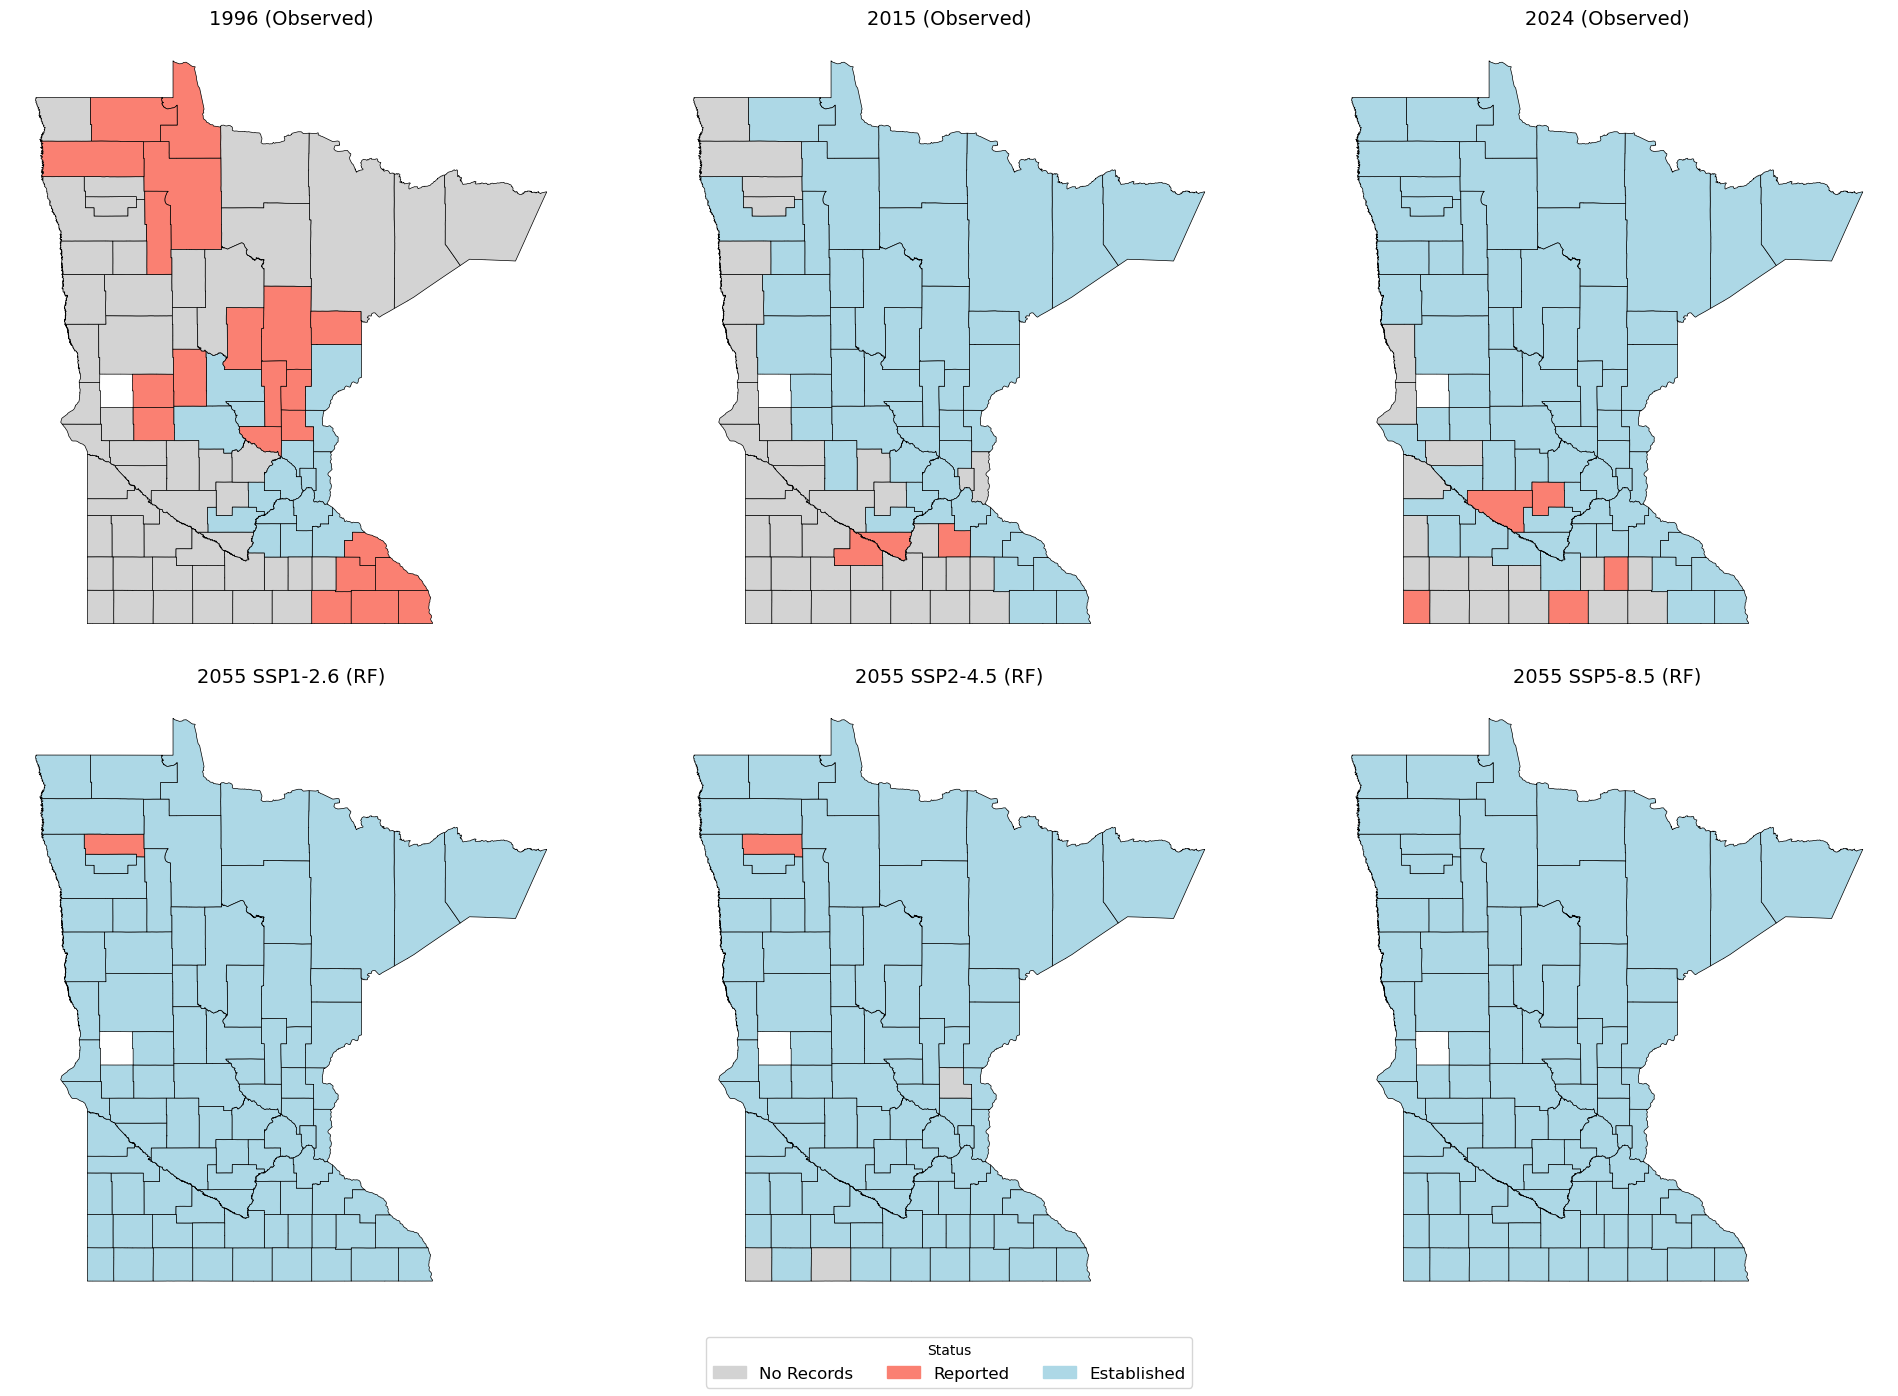

In [146]:
# Map colors for all columns
for year in ['VALUE_1996', 'VALUE_2015', 'VALUE_2024']:
    gdf_map[f'color_{year}'] = gdf_map[year].map(status_colors)
for ssp in ['RF_ssp126', 'RF_ssp245', 'RF_ssp585']:
    gdf_map[f'color_{ssp}'] = gdf_map[ssp].map(status_colors)

# Title mapping
title_map = {
    'VALUE_1996': '1996 (Observed)',
    'VALUE_2015': '2015 (Observed)',
    'VALUE_2024': '2024 (Observed)',
    'RF_ssp126': '2055 SSP1-2.6 (RF)',
    'RF_ssp245': '2055 SSP2-4.5 (RF)',
    'RF_ssp585': '2055 SSP5-8.5 (RF)'
}

columns = ['VALUE_1996', 'VALUE_2015', 'VALUE_2024', 'RF_ssp126', 'RF_ssp245', 'RF_ssp585']
fig, axes = plt.subplots(2, 3, figsize=(20, 14))
for ax, col in zip(axes.flatten(), columns):
    gdf_map.plot(
        color=gdf_map[f'color_{col}'],
        edgecolor='black',
        linewidth=0.5,
        ax=ax
    )
    ax.set_title(title_map[col], fontsize=14)
    ax.axis('off')

legend_patches = [mpatches.Patch(color=status_colors[k], label=status_labels[k]) for k in status_colors]
fig.legend(handles=legend_patches, title="Status", loc='lower center', ncol=3, fontsize=12)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("Tick_Status_mn_Map_w_future.png", dpi=300, bbox_inches='tight')
plt.show()

In [150]:
import sys
print(sys.version)

3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
